In [1]:
# conda env: genomeinfodb-manual-versions2 

**Chromatin loop dynamics during cellular differentiation are associated with changes to both anchor and internal regulatory features** <br>
Bond et al., 2023 <br>
https://genome.cshlp.org/content/33/8/1258 <br>
"We performed a deeply sequenced, three-timepoint Hi-C time course tracking the differentiation of **K562 cells into a megakaryocyte-like state**. We treated K562 cells with phorbol 12-myrisate 13-acetate (PMA), which has been shown to induce a megakaryocyte-like phenotype, for **0, 6, and 72 h.**" "We then performed in situ Hi-C on four biological replicates and sequenced them to a depth of roughly 6 billion reads per time point."


## Download fastq files
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE214123 <br>
https://www.ncbi.nlm.nih.gov/Traces/study/?acc=PRJNA883981&o=acc_s%3Aa <br>
/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC <br>

In [1]:
import pandas as pd

In [2]:
GSM_id=pd.read_csv("/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/GSM_ID.csv", names=['GSM_ID', 'condition'], header=None)

In [3]:
GSM_id.head()

,GSM_ID,condition
0,GSM6599326,HIC_K562_0000min_biorep1_techrep1_seqrep1
1,GSM6599327,HIC_K562_0360min_biorep1_techrep1_seqrep1
2,GSM6599328,HIC_K562_4320min_biorep1_techrep1_seqrep1
3,GSM6599329,HIC_K562_0000min_biorep2_techrep1_seqrep1
4,GSM6599330,HIC_K562_0360min_biorep2_techrep1_seqrep1


In [4]:
SRR_id=pd.read_csv("/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SraRunTable.txt")

In [5]:
SRR_id=pd.merge(GSM_id, SRR_id[['Run','Sample Name']], left_on='GSM_ID', right_on='Sample Name').iloc[:,:-1]
SRR_id.head()

,GSM_ID,condition,Run
0,GSM6599326,HIC_K562_0000min_biorep1_techrep1_seqrep1,SRR21699840
1,GSM6599327,HIC_K562_0360min_biorep1_techrep1_seqrep1,SRR21699839
2,GSM6599328,HIC_K562_4320min_biorep1_techrep1_seqrep1,SRR21699838
3,GSM6599329,HIC_K562_0000min_biorep2_techrep1_seqrep1,SRR21699837
4,GSM6599330,HIC_K562_0360min_biorep2_techrep1_seqrep1,SRR21699836


In [6]:
# data_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/fastq'
# for SRR in SRR_id.Run:
#     !bsub -q "long" -W 20:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 1 -R "rusage[mem=64G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "source ~/.bashrc && conda activate sra-tools && fastq-dump --gzip --outdir $data_dir --split-3 $SRR"


## Generate mcool files using distiller

### Create a yml file as input for distiller pipeline

In [7]:
import yaml

In [8]:
fastq_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/fastq/'
raw_reads_paths={}
for time_point in ['HIC_K562_0000min','HIC_K562_0360min','HIC_K562_4320min']:
    for biorep in ['biorep1','biorep2','biorep3','biorep4']:
        df=SRR_id.loc[SRR_id.condition.str.contains(f'{time_point}_{biorep}')].reset_index(drop=True)
        biorep_dict={}
        for i in range(len(df)):
            biorep_dict[f'lane{i+1}']=[fastq_dir+df.Run[i]+'_1.fastq.gz',fastq_dir+df.Run[i]+'_2.fastq.gz']
        raw_reads_paths[f'{time_point}_{biorep}__hg38']=biorep_dict
        

In [9]:
library_groups={
    'HIC_K562_0000min_pool': [x + '_' + y + z for x, y, z in zip(['HIC_K562_0000min']*4, ['biorep1','biorep2','biorep3','biorep4'], ['__hg38']*4)],
    'HIC_K562_0360min_pool': [x + '_' + y + z for x, y, z in zip(['HIC_K562_0360min']*4, ['biorep1','biorep2','biorep3','biorep4'], ['__hg38']*4)],
    'HIC_K562_4320min_pool': [x + '_' + y + z for x, y, z in zip(['HIC_K562_4320min']*4, ['biorep1','biorep2','biorep3','biorep4'], ['__hg38']*4)],
    'MEGA': [x + '_' + y + z for x, y, z in zip(['HIC_K562_0000min']*4, ['biorep1','biorep2','biorep3','biorep4'], ['__hg38']*4)] + [x + '_' + y + z for x, y, z in zip(['HIC_K562_0360min']*4, ['biorep1','biorep2','biorep3','biorep4'], ['__hg38']*4)] + [x + '_' + y + z for x, y, z in zip(['HIC_K562_4320min']*4, ['biorep1','biorep2','biorep3','biorep4'], ['__hg38']*4)]
}


In [10]:
# # Generated a distiller project yml file template from clims
# with open('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/distiller-project.yml', 'r') as read_file:
#     contents=yaml.safe_load(read_file)
#     # Need to replace:
#     # contents['input']['raw_reads_paths']
#     # contents['input']['library_groups']
#     contents['input']['raw_reads_paths']=raw_reads_paths
#     contents['input']['library_groups']=library_groups

# with open('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/Bond_et_al_2023.yml', 'w') as dump_file:
#     yaml.dump(contents, dump_file, sort_keys=False)

In [11]:
# Run distiller
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers
# bsub < run.sh

### Create a yml file for each biorep and run distiller one by one (delete fastq folder manually after finished)

In [12]:
import yaml
import pandas as pd

In [13]:
fastq_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/fastq/'
raw_reads_paths={}
for time_point in ['HIC_K562_0000min','HIC_K562_0360min','HIC_K562_4320min']:
    for biorep in ['biorep1','biorep2','biorep3','biorep4']:
        df=SRR_id.loc[SRR_id.condition.str.contains(f'{time_point}_{biorep}')].reset_index(drop=True)
        biorep_dict={}
        for i in range(len(df)):
            biorep_dict[f'lane{i+1}']=[fastq_dir+df.Run[i]+'_1.fastq.gz',fastq_dir+df.Run[i]+'_2.fastq.gz']
        raw_reads_paths[f'{time_point}_{biorep}__hg38']=biorep_dict
        

In [14]:
# for key, value in raw_reads_paths.items():
#     # Generated a distiller project yml file template from clims
#     with open('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/distiller-project.yml', 'r') as read_file:
#         contents=yaml.safe_load(read_file)
#         # Need to replace:
#         # contents['input']['raw_reads_paths']
#         # contents['input']['library_groups']
#         contents['input']['raw_reads_paths']={key: value}
#         contents['input']['library_groups']='' # no group for each biorep
    
#     with open(f'/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/ymls/{key}.yml', 'w') as dump_file:
#         yaml.dump(contents, dump_file, sort_keys=False)
        

In [15]:
bioreps=list(raw_reads_paths.keys())
bioreps

['HIC_K562_0000min_biorep1__hg38',
 'HIC_K562_0000min_biorep2__hg38',
 'HIC_K562_0000min_biorep3__hg38',
 'HIC_K562_0000min_biorep4__hg38',
 'HIC_K562_0360min_biorep1__hg38',
 'HIC_K562_0360min_biorep2__hg38',
 'HIC_K562_0360min_biorep3__hg38',
 'HIC_K562_0360min_biorep4__hg38',
 'HIC_K562_4320min_biorep1__hg38',
 'HIC_K562_4320min_biorep2__hg38',
 'HIC_K562_4320min_biorep3__hg38',
 'HIC_K562_4320min_biorep4__hg38']

In [16]:
# Run distiller
# Need to modify project file and create output folder one by one

# HIC_K562_0000min_biorep1__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0000min_biorep1__hg38
# bsub < run.sh

In [17]:
# HIC_K562_0000min_biorep2__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0000min_biorep2__hg38
# bsub < run.sh

In [18]:
# HIC_K562_0000min_biorep3__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0000min_biorep3__hg38
# bsub < run.sh

In [19]:
# HIC_K562_0000min_biorep4__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0000min_biorep4__hg38
# bsub < run.sh

In [20]:
# HIC_K562_0360min_biorep1__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0360min_biorep1__hg38
# bsub < run.sh

In [21]:
# HIC_K562_0360min_biorep2__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0360min_biorep2__hg38
# bsub < run.sh

In [22]:
# HIC_K562_0360min_biorep3__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0360min_biorep3__hg38
# bsub < run.sh

In [23]:
# HIC_K562_0360min_biorep4__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_0360min_biorep4__hg38
# bsub < run.sh

In [24]:
# HIC_K562_4320min_biorep1__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_4320min_biorep1__hg38
# bsub < run.sh

In [25]:
# HIC_K562_4320min_biorep2__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_4320min_biorep2__hg38
# bsub < run.sh

In [26]:
# HIC_K562_4320min_biorep3__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_4320min_biorep3__hg38
# bsub < run.sh

In [27]:
# HIC_K562_4320min_biorep4__hg38
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/HIC_K562_4320min_biorep4__hg38
# bsub < run.sh

## Merge mcool files of bioreps per time point

In [28]:
# hictk --version
# hictk-v1.0.0-bioconda

In [29]:
clr_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/'
# 0000min
min0000_cool=[]
for i in bioreps[:4]:
    min0000_cool.append(f'{clr_dir}{i}/results/coolers_library/{i}.hg38.mapq_30.1000.mcool::resolutions/1000')
min0000_cool=' '.join(min0000_cool)

# 0360min
min0360_cool=[]
for i in bioreps[4:8]:
    min0360_cool.append(f'{clr_dir}{i}/results/coolers_library/{i}.hg38.mapq_30.1000.mcool::resolutions/1000')
min0360_cool=' '.join(min0360_cool)

# 4320min
min4320_cool=[]
for i in bioreps[8:]:
    min4320_cool.append(f'{clr_dir}{i}/results/coolers_library/{i}.hg38.mapq_30.1000.mcool::resolutions/1000')
min4320_cool=' '.join(min4320_cool)

In [30]:
min0000_merged_1000=f'{clr_dir}HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.1000.cool'
min0360_merged_1000=f'{clr_dir}HIC_K562_0360min_biorep1_to_4__hg38.hg38.mapq_30.1000.cool'
min4320_merged_1000=f'{clr_dir}HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.1000.cool'

In [31]:
# # 0000min
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate hictk && hictk merge -o $min0000_merged_1000 --threads 8 $min0000_cool"


In [32]:
# # 0360min
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate hictk && hictk merge -o $min0360_merged_1000 --threads 8 $min0360_cool"


In [33]:
# # 4320min
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate hictk && hictk merge -o $min4320_merged_1000 --threads 8 $min4320_cool"


In [34]:
min0000_merged_mcool=f'{clr_dir}HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
min0360_merged_mcool=f'{clr_dir}HIC_K562_0360min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
min4320_merged_mcool=f'{clr_dir}HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'

In [62]:
# # 0000min balanced
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=16G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate genomeinfodb-manual-versions2 && cooler zoomify --nproc 4 --resolutions 1000,2000,5000,10000 --balance --out $min0000_merged_mcool $min0000_merged_1000"


INFO: Total memory requested is 65536 MB (4 cores x 16384 MB)
Job <172451> is submitted to queue <long>.


In [63]:
# # 0360min balanced
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=16G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate genomeinfodb-manual-versions2 && cooler zoomify --nproc 4 --resolutions 1000,2000,5000,10000 --balance --out $min0360_merged_mcool $min0360_merged_1000"


INFO: Total memory requested is 65536 MB (4 cores x 16384 MB)
Job <172452> is submitted to queue <long>.


In [64]:
# # 4320min balanced
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=16G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate genomeinfodb-manual-versions2 && cooler zoomify --nproc 4 --resolutions 1000,2000,5000,10000 --balance --out $min4320_merged_mcool $min4320_merged_1000"


INFO: Total memory requested is 65536 MB (4 cores x 16384 MB)
Job <172453> is submitted to queue <long>.


## Generate MEGA mcool

In [51]:
clr_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/'

all_cool=[]
for i in bioreps:
    all_cool.append(f'{clr_dir}{i}/results/coolers_library/{i}.hg38.mapq_30.1000.mcool::resolutions/1000')
all_cool=' '.join(all_cool)

In [52]:
all_merged_1000=f'{clr_dir}HIC_K562_0000_0360_4320_biorep1_to_4__hg38.hg38.mapq_30.1000.cool'

In [53]:
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate hictk && hictk merge -o $all_merged_1000 --threads 8 $all_cool"


In [54]:
all_merged_mcool=f'{clr_dir}HIC_K562_0000_0360_4320_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'

In [65]:
# # balanced
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=16G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "source ~/.bashrc && conda activate genomeinfodb-manual-versions2 && cooler zoomify --nproc 4 --resolutions 1000,2000,5000,10000 --balance --out $all_merged_mcool $all_merged_1000"


INFO: Total memory requested is 65536 MB (4 cores x 16384 MB)
Job <172454> is submitted to queue <long>.


## Check number of reads and cis and trans ratios after ignore_diags=2 (default IC balancing) at 5 and 10kb resolutions¶

In [1]:
import pandas as pd

In [2]:
clr_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/'

coolers = {'name': ['K562_0000min',
                    'K562_0360min',
                    'K562_4320min',
                    'MEGA'],
           'path': [clr_dir+'HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool',
                    clr_dir+'HIC_K562_0360min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool',
                    clr_dir+'HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool',
                    clr_dir+'HIC_K562_0000_0360_4320_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
                   ]} 
coolers = pd.DataFrame.from_dict(coolers)

# coolers.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv', sep='\t', index=False, header=True)


In [3]:
input_cooler_paths='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
resolutions='5000,10000'
ignore_diags=2
output='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/cis_trans_count_summary_5_and_10kb.tsv'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 1 -R "rusage[mem=256G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/calculate_cis_trans_counts_after_ignoring_specific_diagonals.py $input_cooler_paths $resolutions $ignore_diags $output"


In [4]:
count_summary=pd.read_csv(output, sep='\t')

In [5]:
count_summary

,condition,total,total_trans,total_cis,total_cis_without_2_diags,total_trans_percent,total_cis_percent,total_cis_without_2_diags_percent,resolution
0,K562_0000min,2898914999,395597111,2503317888,1781071140,0.136464,0.863536,0.614392,5000
1,K562_0360min,2933402473,536619076,2396783397,1680444179,0.182934,0.817066,0.572865,5000
2,K562_4320min,3081052500,512908981,2568143519,1901705698,0.166472,0.833528,0.617226,5000
3,MEGA,8913369972,1445125168,7468244804,5363221017,0.162130,0.837870,0.601705,5000
4,K562_0000min,2898914999,395597111,2503317888,1661160717,0.136464,0.863536,0.573028,10000
5,K562_0360min,2933402473,536619076,2396783397,1588990645,0.182934,0.817066,0.541689,10000
6,K562_4320min,3081052500,512908981,2568143519,1783272380,0.166472,0.833528,0.578787,10000
7,MEGA,8913369972,1445125168,7468244804,5033423742,0.162130,0.837870,0.564705,10000


In [8]:
count_summary=pd.read_csv(output, sep='\t')[['condition','total','total_trans','total_trans_percent','total_cis','total_cis_percent','total_cis_without_2_diags','total_cis_without_2_diags_percent','resolution']]
count_summary['total'] = count_summary['total'].apply(lambda x: f'{x:,}')
count_summary['total_trans'] = count_summary['total_trans'].apply(lambda x: f'{x:,}')
count_summary['total_cis'] = count_summary['total_cis'].apply(lambda x: f'{x:,}')
count_summary['total_cis_without_2_diags'] = count_summary['total_cis_without_2_diags'].apply(lambda x: f'{x:,}')
count_summary.loc[count_summary.resolution == 5000, ['condition','total','total_trans','total_trans_percent','total_cis','total_cis_percent']].reset_index(drop=True)


,condition,total,total_trans,total_trans_percent,total_cis,total_cis_percent
0,K562_0000min,"2,898,914,999","395,597,111",0.136464,"2,503,317,888",0.863536
1,K562_0360min,"2,933,402,473","536,619,076",0.182934,"2,396,783,397",0.817066
2,K562_4320min,"3,081,052,500","512,908,981",0.166472,"2,568,143,519",0.833528
3,MEGA,"8,913,369,972","1,445,125,168",0.162130,"7,468,244,804",0.837870


dotfinder.py
**ValueError: Provided cooler has resolution 2000 bases, which is too fine for automated kernel recommendation. Provide custom kernels to proceed.**

## Old method: Generate a union list of loops by overlapping loops called from each individual libraries at 5kb resolution

### Call loops at 5kb resolution for each individual library (used for later comparison with my optimized method)

In [1]:
input_coolers='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
output_folder='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/Generate_dots_from_each_individual_libraries.py $input_coolers $output_folder"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <185242> is submitted to queue <long>.


### Merge loops called from each individual library

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_meta=pd.read_csv(dots_dir+'dots_meta_5kb.tsv', sep='\t')

In [3]:
dots_meta

,name,path
0,K562_0000min,/home/jiangyuan.liu5-umw/projects/4DNII/public...
1,K562_0360min,/home/jiangyuan.liu5-umw/projects/4DNII/public...
2,K562_4320min,/home/jiangyuan.liu5-umw/projects/4DNII/public...
3,MEGA,/home/jiangyuan.liu5-umw/projects/4DNII/public...


In [4]:
dots_list=[]
for i in range(len(dots_meta)):
    df=pd.read_csv(dots_meta.path[i], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    df['sample_name']=dots_meta.name[i]
    dots_list.append(df)
dots=pd.concat(dots_list)

In [5]:
import bioframe
import pandas as pd
import numpy as np

def merge_dots(df):
    overlapped_anchors_left=bioframe.cluster(df[['chrom1','start1','end1']].copy().rename(columns={'chrom1': 'chrom', 'start1': 'start', 'end1': 'end'}), min_dist=None)
    overlapped_anchors_right=bioframe.cluster(df[['chrom2','start2','end2','sample_name']].copy().rename(columns={'chrom2': 'chrom', 'start2': 'start', 'end2': 'end'}), min_dist=None)
    overlapped_dots=pd.merge(overlapped_anchors_left, overlapped_anchors_right, left_index=True, right_index=True, suffixes=(1,2))
    sample_name=overlapped_dots.groupby(['cluster1','cluster2'])['sample_name'].apply(lambda x: '&'.join(list(np.unique(x)))).reset_index()
    overlapped_dots=pd.merge(overlapped_dots[['cluster1','cluster2','chrom1','cluster_start1','cluster_end1','chrom2','cluster_start2','cluster_end2']], sample_name, on=['cluster1','cluster2'])
    overlapped_dots=overlapped_dots.drop(['cluster1', 'cluster2'], axis=1).rename(columns={'cluster_start1': 'start1', 'cluster_end1': 'end1', 'cluster_start2': 'start2', 'cluster_end2': 'end2'})
    overlapped_dots=overlapped_dots.drop_duplicates().reset_index(drop=True)
    return overlapped_dots



In [6]:
merged_dots=merge_dots(dots)

In [7]:
len(merged_dots) # Total 12492 loops

12492

In [8]:
# For testing purpose
# Since all anchors are same resolution, we can simplify merge_dots() with below two lines in the future
df=dots.reset_index(drop=True).copy()
a=df.groupby(['chrom1','start1','end1','chrom2','start2','end2'])['sample_name'].apply(lambda x: '&'.join(list(np.unique(x)))).reset_index()

are_equal = merged_dots.sort_values(by=merged_dots.columns.tolist()).reset_index(drop=True).equals(
    a.sort_values(by=a.columns.tolist()).reset_index(drop=True)
)
print("DataFrames are equal (ignoring row order):", are_equal)

DataFrames are equal (ignoring row order): True


In [9]:
merged_dots

,chrom1,start1,end1,chrom2,start2,end2,sample_name
0,chr10,32795000,32800000,chr10,33005000,33010000,K562_0000min&MEGA
1,chr10,30415000,30420000,chr10,30530000,30535000,K562_0000min&K562_4320min&MEGA
2,chr10,30390000,30395000,chr10,30590000,30595000,K562_0000min&K562_4320min&MEGA
3,chr10,35120000,35125000,chr10,35210000,35215000,K562_0000min&K562_0360min
4,chr10,28665000,28670000,chr10,28990000,28995000,K562_0000min&K562_0360min&K562_4320min&MEGA
...,...,...,...,...,...,...,...
12487,chrX,65575000,65580000,chrX,66725000,66730000,MEGA
12488,chrX,71420000,71425000,chrX,71645000,71650000,MEGA
12489,chrX,69540000,69545000,chrX,70090000,70095000,MEGA
12490,chrX,73855000,73860000,chrX,74340000,74345000,MEGA


In [13]:
# merged_dots.to_csv(dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt', sep='\t', index=False, header=True)


### Generate clusters of enriched pixels for each individual library

In [2]:
input_coolers='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
output_folder='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/clusters'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_clusters_of_enriched_pixels.py $input_coolers $output_folder"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <715727> is submitted to queue <long>.


### Generate centroids of clusters for each individual library (i.e., cluster_filtering=False in dots())

In [3]:
input_coolers='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
output_folder='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/Generate_dots_from_each_individual_libraries_no_HiCCUPS_filtering.py $input_coolers $output_folder"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <715728> is submitted to queue <long>.


### Annotate centroid dataframe with columns, including removed (bool), c_start1, c_end1, c_start2, c_end2 (for its cluster)

In [1]:
import pandas as pd
import numpy as np

In [2]:
clusters_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/clusters/clusters_meta_5kb.tsv'
centroids_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/dots_meta_5kb_no_HiCCUPS_filtering.tsv'
loops_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/dots_meta_5kb.tsv'

clusters_meta=pd.read_csv(clusters_meta, sep='\t').set_index('name')['path'].to_dict()
centroids_meta=pd.read_csv(centroids_meta, sep='\t').set_index('name')['path'].to_dict()
loops_meta=pd.read_csv(loops_meta, sep='\t').set_index('name')['path'].to_dict()


In [3]:
import pandas as pd
import numpy as np

def annotate_centroid_df(clusters, centroids, loops):
    clusters=pd.read_csv(clusters,sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size']]
    centroids=pd.read_csv(centroids,sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size']]
    loops=pd.read_csv(loops,sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size']]

    clusters=clusters.groupby(['region', 'c_label']).agg(
        c_start1=('start1', 'min'),
        c_end1=('end1', 'max'),
        c_start2=('start2', 'min'),
        c_end2=('end2', 'max')
    ).reset_index()

    centroids=pd.merge(centroids, clusters, on=['region','c_label'])

    centroids_annotated=pd.merge(centroids, loops, on=['region','c_label'], how='left', indicator=True, suffixes=('', '_loop'))
    centroids_annotated['removed']=False
    centroids_annotated.loc[centroids_annotated._merge == 'left_only', 'removed']=True
    centroids_annotated=centroids_annotated[list(centroids.columns)+['removed']]
    centroids_annotated['centroid_ID']=list(centroids_annotated.index)
    
    return centroids_annotated
    

In [4]:
conditions=['K562_0000min','K562_0360min','K562_4320min']

annotated_centroids={}
for cond in conditions:
    annotated_centroids[cond]=annotate_centroid_df(clusters_meta[cond], centroids_meta[cond], loops_meta[cond])


In [5]:
# centroid_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/'
# annotated_centroids['K562_0000min'].to_csv(centroid_dir+'HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.5kb.dots.no.HiCCUPS.filtering.annotated.tsv', sep='\t', index=False, header=True)
# annotated_centroids['K562_0360min'].to_csv(centroid_dir+'HIC_K562_0360min_biorep1_to_4__hg38.hg38.mapq_30.5kb.dots.no.HiCCUPS.filtering.annotated.tsv', sep='\t', index=False, header=True)
# annotated_centroids['K562_4320min'].to_csv(centroid_dir+'HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.5kb.dots.no.HiCCUPS.filtering.annotated.tsv', sep='\t', index=False, header=True)


In [6]:
# centroid_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/'
# annotate_centroid_df(clusters_meta['MEGA'], centroids_meta['MEGA'], loops_meta['MEGA']).to_csv(centroid_dir+'HIC_K562_0000_0360_4320_biorep1_to_4__hg38.hg38.mapq_30.5kb.dots.no.HiCCUPS.filtering.annotated.tsv', sep='\t', index=False, header=True)


In [7]:
annotated_centroids['K562_0000min']

,chrom1,start1,end1,chrom2,start2,end2,region,c_label,c_size,c_start1,c_end1,c_start2,c_end2,removed,centroid_ID
0,chr10,32255000,32260000,chr10,32355000,32360000,chr10_p,0,5,32250000,32265000,32355000,32370000,True,0
1,chr10,35250000,35255000,chr10,35325000,35330000,chr10_p,1,1,35250000,35255000,35325000,35330000,True,1
2,chr10,32795000,32800000,chr10,33005000,33010000,chr10_p,2,16,32785000,32810000,32995000,33025000,False,2
3,chr10,30415000,30420000,chr10,30530000,30535000,chr10_p,3,15,30390000,30420000,30520000,30545000,False,3
4,chr10,30390000,30395000,chr10,30590000,30595000,chr10_p,4,15,30390000,30420000,30580000,30605000,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9673,chrX,65570000,65575000,chrX,66405000,66410000,chrX_q,90,1,65570000,65575000,66405000,66410000,True,9673
9674,chrX,77695000,77700000,chrX,77860000,77865000,chrX_q,91,1,77695000,77700000,77860000,77865000,True,9674
9675,chrX,68825000,68830000,chrX,69375000,69380000,chrX_q,92,1,68825000,68830000,69375000,69380000,True,9675
9676,chrX,87335000,87340000,chrX,87660000,87665000,chrX_q,93,1,87335000,87340000,87660000,87665000,True,9676


### Investigate removed enriched pixles by HICCUPS filtering (we will test how many of them are rescued by my new method later when we compare old and new methods).

https://github.com/open2c/cooltools/blob/ab97a0461a9b3b642f36c7597cd17b852c075d46/cooltools/api/dotfinder.py#L1139 <br>
HICCUPS filtering removed two types of centroids:
1. Centroids are filtered on enrichment relative to the locally-adjusted expected for the "donut", "lowleft", "vertical", and "horizontal" kernels.
2. Singleton pixels (i.e. pixels that do not belong to a cluster) are filtered based on a combined q-values for all kernels. <br>


This empirical filtering approach was developed in Rao et al 2014 and results in a conservative dot-calls with the low rate of false-positive calls.

In [7]:
for cond in conditions:
    print(cond)
    centroids_df=annotated_centroids[cond]
    print(f'Type 1: #Removed centroids: {len(centroids_df.loc[(centroids_df.removed) & (centroids_df.c_size > 1)])}')
    print(f'Type 2: #Removed singletons: {len(centroids_df.loc[(centroids_df.removed) & (centroids_df.c_size == 1)])}')
    print(f'#Final loops: {len(centroids_df.loc[~(centroids_df.removed)])}')
    print('')

K562_0000min
Type 1: #Removed centroids: 1776
Type 2: #Removed singletons: 3814
#Final loops: 4088

K562_0360min
Type 1: #Removed centroids: 1164
Type 2: #Removed singletons: 2776
#Final loops: 3030

K562_4320min
Type 1: #Removed centroids: 1860
Type 2: #Removed singletons: 4990
#Final loops: 5818



In [8]:
# generate_stack_of_pileup_of_centroids_in_0h_at_0_6_72_cooler_5kb_resolution_50kb_flank.py

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/Bond_et_al_2023/generate_stack_of_pileup_of_centroids_in_0h_at_0_6_72_cooler_5kb_resolution_50kb_flank.py"


### Show examples: removed centroids in 0h have neighboring enriched pixels from 6 and 72h using old method

In [8]:
# two types of removed centroids in 0h
centroids_df=annotated_centroids['K562_0000min']
# Type 1
removed_centroids_0h=centroids_df.loc[(centroids_df.removed) & (centroids_df.c_size > 1), ['chrom1','start1','end1','chrom2','start2','end2','centroid_ID']]
# Type 2
removed_singletons_0h=centroids_df.loc[(centroids_df.removed) & (centroids_df.c_size == 1), ['chrom1','start1','end1','chrom2','start2','end2','centroid_ID']]

kept_centroids_0h=centroids_df.loc[(~(centroids_df.removed)) & (centroids_df.c_size > 1), ['chrom1','start1','end1','chrom2','start2','end2','centroid_ID']]
kept_singletons_0h=centroids_df.loc[(~(centroids_df.removed)) & (centroids_df.c_size == 1), ['chrom1','start1','end1','chrom2','start2','end2','centroid_ID']]


In [9]:
# Use my new method to find those two types of removed centroids in 0h overlapped with enriched pixels of 6 and 72h (generated later in this script)
clusters_new='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'
clusters_new=pd.read_csv(clusters_new, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size']]
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv'
dots=pd.read_csv(dots_file, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','sample_name']]

dots_in_0_6_72h=dots.loc[(dots.sample_name.str.contains('K562_0000min')) &
                         (dots.sample_name.str.contains('K562_0360min')) &
                         (dots.sample_name.str.contains('K562_4320min'))]
# Also we know some these removed centroids were rescued by clustering with enriched pixels in MEGA library.
# We will not mention MEGA here. Just give examples that those removed centroids in 0h could be true positive based on 6 and 72h

clusters_in_0_6_72h=pd.merge(clusters_new, dots_in_0_6_72h, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')[['region','c_label','sample_name']]

# Those wrongly removed pixels at 0h have neighboring enriched pixels at 6 and 72h:
# These removed pixels at 0h are more likely to be true positive calls.
# Type 1
removed_centroids_0h_overlapped_clusters_new=pd.merge(removed_centroids_0h, clusters_new, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')
removed_centroids_0h_overlapped_clusters_new_in_0_6_72h=pd.merge(removed_centroids_0h_overlapped_clusters_new, clusters_in_0_6_72h, on=['region','c_label'])
# Type 2
removed_singletons_0h_overlapped_clusters_new=pd.merge(removed_singletons_0h, clusters_new, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')
removed_singletons_0h_overlapped_clusters_new_in_0_6_72h=pd.merge(removed_singletons_0h_overlapped_clusters_new, clusters_in_0_6_72h, on=['region','c_label'])


In [10]:
# Try to find those removed enriched pixels at 0h rescued by MEGA only
dots_in_one_of_three_time_points_and_MEGA=dots.loc[(dots.sample_name == 'K562_0000min&MEGA') | (dots.sample_name == 'K562_0360min&MEGA') | (dots.sample_name == 'K562_4320min&MEGA')]
clusters_in_one_of_three_time_points_and_MEGA=pd.merge(clusters_new, dots_in_one_of_three_time_points_and_MEGA, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')[['region','c_label','sample_name']]
# Type 1
removed_centroids_0h_overlapped_clusters_new=pd.merge(removed_centroids_0h, clusters_new, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')
removed_centroids_0h_in_0h_and_MEGA=pd.merge(removed_centroids_0h_overlapped_clusters_new, clusters_in_one_of_three_time_points_and_MEGA, on=['region','c_label'])
# Type 2
removed_singletons_0h_overlapped_clusters_new=pd.merge(removed_singletons_0h, clusters_new, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')
removed_singletons_0h_in_0h_and_MEGA=pd.merge(removed_singletons_0h_overlapped_clusters_new, clusters_in_one_of_three_time_points_and_MEGA, on=['region','c_label'])


In [11]:
# how many loops rescued per time point by MEGA only
dots_in_one_of_three_time_points_and_MEGA.sample_name.value_counts()

K562_4320min&MEGA    2454
K562_0000min&MEGA    1071
K562_0360min&MEGA     403
Name: sample_name, dtype: int64

In [12]:
clusters_new='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'
clusters_new=pd.read_csv(clusters_new, sep='\t')

# perfect example to draw a illustration figure of my new method: centroid_ID 1944
# centroid_ID: 4733
# a=clusters_new.loc[(clusters_new.region == 'chr15_q') & (clusters_new.c_label == 130)]
a=clusters_new.loc[(clusters_new.region == 'chr20_p') & (clusters_new.c_label == 152)]
pd.merge(dots, a, on=['chrom1','start1','end1','chrom2','start2','end2'])

,chrom1,start1,end1,chrom2,start2,end2,sample_name,condition,bin1_id,bin2_id,...,K562_0360min_balanced,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr20,24995000,25000000,chr20,25065000,25070000,K562_0000min&MEGA,K562_0000min&MEGA,547614,547628,...,0.007708,0.008568,0.00902,chr20_p,2.499333e+07,25065000.0,152,3,chr20_p,chr20_p


In [13]:
(24995000 - 24990000)/5000 # centroid_ID: start1: 24990000 (move center pixel one step down)

1.0

In [14]:
(25065000 - 25060000)/5000 # centroid_ID: start2: 25060000 (move center pixel one step right)

1.0

In [15]:
# (41555000 - 41550000)/5000 # centroid_ID: start1: 41550000 (move center pixel one step down)

In [16]:
# (41810000 - 41815000)/5000 # centroid_ID: start2: 41815000 (move center pixel one step left)

In [17]:
len(removed_centroids_0h_in_0h_and_MEGA)

160

In [18]:
# removed_centroids_0h_in_0h_and_MEGA.iloc[20:40]

removed_centroids_0h_in_0h_and_MEGA.iloc[80:100]

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,region,c_label,c_size,sample_name
80,chr20,24990000,24995000,chr20,25060000,25065000,4733,chr20_p,152,3,K562_0000min&MEGA
81,chr20,3785000,3790000,chr20,3855000,3860000,4744,chr20_p,49,3,K562_0000min&MEGA
82,chr20,63550000,63555000,chr20,63670000,63675000,4839,chr20_q,403,3,K562_0000min&MEGA
83,chr20,34535000,34540000,chr20,34765000,34770000,4926,chr20_q,57,4,K562_0000min&MEGA
84,chr20,45135000,45140000,chr20,45285000,45290000,4971,chr20_q,176,4,K562_0000min&MEGA
85,chr21,15725000,15730000,chr21,15810000,15815000,4996,chr21_q,17,3,K562_0000min&MEGA
86,chr21,38805000,38810000,chr21,38910000,38915000,5078,chr21_q,215,3,K562_0000min&MEGA
87,chr22,21710000,21715000,chr22,21790000,21795000,5268,chr22_q,97,4,K562_0000min&MEGA
88,chr22,47620000,47625000,chr22,47840000,47845000,5325,chr22_q,373,8,K562_0000min&MEGA
89,chr2,32005000,32010000,chr2,32120000,32125000,5344,chr2_p,253,2,K562_0000min&MEGA


In [19]:
clusters_new='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'
clusters_new=pd.read_csv(clusters_new, sep='\t')

# perfect example to draw a illustration figure of my new method: centroid_ID 216
a=clusters_new.loc[(clusters_new.region == 'chr10_q') & (clusters_new.c_label == 567)]
pd.merge(dots, a, on=['chrom1','start1','end1','chrom2','start2','end2'])

,chrom1,start1,end1,chrom2,start2,end2,sample_name,condition,bin1_id,bin2_id,...,K562_0360min_balanced,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr10,110745000,110750000,chr10,110890000,110895000,K562_0000min&MEGA,MEGA,357130,357159,...,0.005939,0.006949,0.006432,chr10_q,110749375.0,110890625.0,567,7,chr10_q,chr10_q


In [20]:
(110745000 - 110740000)/5000 # centroid_ID: start1: 110740000 (move center pixel one step down)

1.0

In [21]:
(110890000 - 110885000)/5000 # centroid_ID: start2: 110885000 (move center pixel one step right)

1.0

In [22]:
len(removed_singletons_0h_in_0h_and_MEGA)

656

In [23]:
removed_singletons_0h_in_0h_and_MEGA.iloc[20:40]

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,region,c_label,c_size,sample_name
20,chr10,94360000,94365000,chr10,94445000,94450000,192,chr10_q,446,3,K562_0000min&MEGA
21,chr10,91385000,91390000,chr10,91690000,91695000,194,chr10_q,426,2,K562_0000min&MEGA
22,chr10,110740000,110745000,chr10,110885000,110890000,216,chr10_q,567,7,K562_0000min&MEGA
23,chr10,109880000,109885000,chr10,110135000,110140000,217,chr10_q,554,6,K562_0000min&MEGA
24,chr10,124270000,124275000,chr10,124385000,124390000,231,chr10_q,646,2,K562_0000min&MEGA
25,chr10,112970000,112975000,chr10,113045000,113050000,236,chr10_q,575,2,K562_0000min&MEGA
26,chr10,123125000,123130000,chr10,123555000,123560000,243,chr10_q,636,6,K562_0000min&MEGA
27,chr10,132385000,132390000,chr10,132630000,132635000,248,chr10_q,677,2,K562_0000min&MEGA
28,chr10,114870000,114875000,chr10,115125000,115130000,249,chr10_q,591,2,K562_0000min&MEGA
29,chr10,129020000,129025000,chr10,129165000,129170000,250,chr10_q,665,2,K562_0000min&MEGA


In [24]:
clusters_new='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'
clusters_new=pd.read_csv(clusters_new, sep='\t')

# perfect example to draw a illustration figure of my new method: centroid_ID 546
a=clusters_new.loc[(clusters_new.region == 'chr11_p') & (clusters_new.c_label == 37)]
pd.merge(dots, a, on=['chrom1','start1','end1','chrom2','start2','end2'])

,chrom1,start1,end1,chrom2,start2,end2,sample_name,condition,bin1_id,bin2_id,...,K562_0360min_balanced,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr11,5200000,5205000,chr11,5290000,5295000,K562_0000min&K562_0360min&K562_4320min&MEGA,K562_0000min&K562_4320min&MEGA,362781,362799,...,0.007818,0.01022,0.009607,chr11_p,5.204444e+06,5.293889e+06,37,9,chr11_p,chr11_p


In [25]:
(5200000 - 5205000)/5000 # centroid_ID: start1: 5205000 (move center pixel one step up)

-1.0

In [26]:
(5290000 - 5300000)/5000 # centroid_ID: start2: 5300000 (move center pixel two step left)

-2.0

In [27]:
# removed_centroids_0h_overlapped_clusters_new_in_0_6_72h.head(30)
removed_centroids_0h_overlapped_clusters_new_in_0_6_72h.iloc[50:70]

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,region,c_label,c_size,sample_name
50,chr10,77835000,77840000,chr10,77980000,77985000,428,chr10_q,342,13,K562_0000min&K562_0360min&K562_4320min&MEGA
51,chr10,80690000,80695000,chr10,80920000,80925000,436,chr10_q,379,13,K562_0000min&K562_0360min&K562_4320min&MEGA
52,chr10,79075000,79080000,chr10,79180000,79185000,441,chr10_q,364,14,K562_0000min&K562_0360min&K562_4320min&MEGA
53,chr11,20385000,20390000,chr11,20610000,20615000,447,chr11_p,240,11,K562_0000min&K562_0360min&K562_4320min&MEGA
54,chr11,17730000,17735000,chr11,17980000,17985000,452,chr11_p,197,29,K562_0000min&K562_0360min&K562_4320min&MEGA
55,chr11,17595000,17600000,chr11,17725000,17730000,454,chr11_p,194,21,K562_0000min&K562_0360min&K562_4320min&MEGA
56,chr11,10405000,10410000,chr11,10660000,10665000,481,chr11_p,98,9,K562_0000min&K562_0360min&K562_4320min&MEGA
57,chr11,10660000,10665000,chr11,10735000,10740000,494,chr11_p,103,17,K562_0000min&K562_0360min&K562_4320min&MEGA
58,chr11,12045000,12050000,chr11,12285000,12290000,497,chr11_p,124,17,K562_0000min&K562_0360min&K562_4320min&MEGA
59,chr11,9610000,9615000,chr11,9750000,9755000,511,chr11_p,84,18,K562_0000min&K562_0360min&K562_4320min&MEGA


In [28]:
removed_singletons_0h_overlapped_clusters_new_in_0_6_72h.head(20)

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,region,c_label,c_size,sample_name
0,chr10,28640000,28645000,chr10,29300000,29305000,9,chr10_p,245,14,K562_0000min&K562_0360min&K562_4320min&MEGA
1,chr10,24735000,24740000,chr10,25060000,25065000,42,chr10_p,201,3,K562_0000min&K562_0360min&K562_4320min&MEGA
2,chr10,23320000,23325000,chr10,23520000,23525000,50,chr10_p,184,14,K562_0000min&K562_0360min&K562_4320min&MEGA
3,chr10,26625000,26630000,chr10,27320000,27325000,57,chr10_p,222,5,K562_0000min&K562_0360min&K562_4320min&MEGA
4,chr10,17605000,17610000,chr10,17870000,17875000,89,chr10_p,138,6,K562_0000min&K562_0360min&K562_4320min&MEGA
5,chr10,6110000,6115000,chr10,6200000,6205000,109,chr10_p,20,7,K562_0000min&K562_0360min&K562_4320min&MEGA
6,chr10,97750000,97755000,chr10,97860000,97865000,117,chr10_q,475,14,K562_0000min&K562_0360min&K562_4320min&MEGA
7,chr10,102225000,102230000,chr10,102395000,102400000,129,chr10_q,519,23,K562_0000min&K562_0360min&K562_4320min&MEGA
8,chr10,95695000,95700000,chr10,95845000,95850000,148,chr10_q,454,13,K562_0000min&K562_0360min&K562_4320min&MEGA
9,chr10,95690000,95695000,chr10,95860000,95865000,195,chr10_q,454,13,K562_0000min&K562_0360min&K562_4320min&MEGA


In [29]:
dots_in_0h_only=dots.loc[(dots.sample_name.str.contains('K562_0000min')) &
                         (~(dots.sample_name.str.contains('K562_0360min'))) &
                         (~(dots.sample_name.str.contains('K562_4320min'))) &
                         (~(dots.sample_name.str.contains('MEGA')))]

clusters_in_0h_only=pd.merge(clusters_new, dots_in_0h_only, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')[['region','c_label','sample_name']]

# Those correctly removed pixels at 0h also not neighboring enriched pixels at 6, 72h, and MEGA:
# These removed pixels at 0h are more likely to be false positive calls.
# Type 1
removed_centroids_0h_overlapped_clusters_new_in_0h_only=pd.merge(removed_centroids_0h_overlapped_clusters_new, clusters_in_0h_only, on=['region','c_label'])
# Type 2
removed_singletons_0h_overlapped_clusters_new_in_0h_only=pd.merge(removed_singletons_0h_overlapped_clusters_new, clusters_in_0h_only, on=['region','c_label'])


In [30]:
removed_centroids_0h_overlapped_clusters_new_in_0h_only

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,region,c_label,c_size,sample_name
0,chr10,50325000,50330000,chr10,50410000,50415000,260,chr10_q,64,2,K562_0000min
1,chr10,45015000,45020000,chr10,45220000,45225000,287,chr10_q,23,3,K562_0000min
2,chr11,10200000,10205000,chr11,10320000,10325000,501,chr11_p,94,2,K562_0000min
3,chr11,840000,845000,chr11,1045000,1050000,560,chr11_p,6,4,K562_0000min
4,chr11,68040000,68045000,chr11,68125000,68130000,910,chr11_q,166,2,K562_0000min
5,chr11,61895000,61900000,chr11,62055000,62060000,957,chr11_q,74,2,K562_0000min
6,chr12,23420000,23425000,chr12,23555000,23560000,1058,chr12_p,110,2,K562_0000min
7,chr12,129910000,129915000,chr12,130010000,130015000,1154,chr12_q,816,2,K562_0000min
8,chr12,104380000,104385000,chr12,104450000,104455000,1282,chr12_q,489,2,K562_0000min
9,chr14,20470000,20475000,chr14,20590000,20595000,1629,chr14_q,3,2,K562_0000min


In [31]:
# removed_centroids_0h_overlapped_clusters_new_in_0h_only.iloc[40:60]
# removed_singletons_0h_overlapped_clusters_new_in_0h_only.head(30)

In [32]:
removed_singletons_0h_overlapped_clusters_new_in_0h_only

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,region,c_label,c_size,sample_name
0,chr1,75240000,75245000,chr1,75610000,75615000,4037,chr1_p,1041,2,K562_0000min
1,chr1,75255000,75260000,chr1,75580000,75585000,4062,chr1_p,1041,2,K562_0000min
2,chr1,233615000,233620000,chr1,233790000,233795000,4282,chr1_q,921,1,K562_0000min
3,chr1,200370000,200375000,chr1,200515000,200520000,4411,chr1_q,512,2,K562_0000min
4,chr1,200350000,200355000,chr1,200480000,200485000,4419,chr1_q,512,2,K562_0000min
5,chr3,100460000,100465000,chr3,100590000,100595000,6469,chr3_q,15,1,K562_0000min
6,chr7,139660000,139665000,chr7,139835000,139840000,8651,chr7_q,677,1,K562_0000min


In [33]:
# for those centroids passed filtering steps
kept_centroids_0h_overlapped_clusters_new=pd.merge(kept_centroids_0h, clusters_new, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')
# clusters of centroids of new method in 0h only 
kept_centroids_0h_overlapped_clusters_new_in_0h_only=pd.merge(kept_centroids_0h_overlapped_clusters_new, clusters_in_0h_only, on=['region','c_label'])
# clusters of centroids of new method in 0, 6, and 72h.
kept_centroids_0h_overlapped_clusters_new_in_0_6_72h=pd.merge(kept_centroids_0h_overlapped_clusters_new, clusters_in_0_6_72h, on=['region','c_label'])


In [34]:
clusters_new='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'
clusters_new=pd.read_csv(clusters_new, sep='\t')

# perfect example to draw a illustration figure of my new method: centroid_ID 1643
a=clusters_new.loc[(clusters_new.region == 'chr14_q') & (clusters_new.c_label == 99)]
pd.merge(dots, a, on=['chrom1','start1','end1','chrom2','start2','end2'])

,chrom1,start1,end1,chrom2,start2,end2,sample_name,condition,bin1_id,bin2_id,...,K562_0360min_balanced,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr14,36225000,36230000,chr14,36380000,36385000,K562_0000min,K562_0000min,445533,445564,...,0.004078,0.004202,0.005454,chr14_q,36232500.0,36375000.0,99,2,chr14_q,chr14_q


In [35]:
a

,chrom1,start1,end1,chrom2,start2,end2,condition,bin1_id,bin2_id,K562_0000min_balanced,K562_0360min_balanced,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2
34486,chr14,36225000,36230000,chr14,36380000,36385000,K562_0000min,445533,445564,0.008038,0.004078,0.004202,0.005454,chr14_q,36232500.0,36375000.0,99,2,chr14_q,chr14_q
34487,chr14,36240000,36245000,chr14,36370000,36375000,K562_0000min,445536,445562,0.008003,0.005054,0.003753,0.005660,chr14_q,36232500.0,36375000.0,99,2,chr14_q,chr14_q


In [36]:
kept_centroids_0h_overlapped_clusters_new_in_0h_only.head(20)

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,condition,bin1_id,bin2_id,...,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2,sample_name
0,chr11,13775000,13780000,chr11,14245000,14250000,495,K562_0000min,364496,364590,...,0.005200,0.004495,chr11_p,1.377333e+07,1.423917e+07,151,6,chr11_p,chr11_p,K562_0000min
1,chr11,13775000,13780000,chr11,13955000,13960000,506,K562_0000min,364496,364532,...,0.004884,0.004952,chr11_p,1.377417e+07,1.395083e+07,150,6,chr11_p,chr11_p,K562_0000min
2,chr11,86455000,86460000,chr11,86815000,86820000,778,K562_0000min,379032,379104,...,0.005519,0.005881,chr11_q,8.645200e+07,8.681600e+07,376,5,chr11_q,chr11_q,K562_0000min
3,chr11,58635000,58640000,chr11,58905000,58910000,979,K562_0000min,373468,373522,...,0.003076,0.003648,chr11_q,5.864000e+07,5.890167e+07,29,3,chr11_q,chr11_q,K562_0000min
4,chr12,8680000,8685000,chr12,8825000,8830000,1026,K562_0000min,390495,390524,...,0.004724,0.006943,chr12_p,8.681667e+06,8.818333e+06,218,3,chr12_p,chr12_p,K562_0000min
5,chr12,93520000,93525000,chr12,94100000,94105000,1211,K562_0000min,407463,407579,...,0.004436,0.005181,chr12_q,9.351846e+07,9.409577e+07,392,11,chr12_q,chr12_q,K562_0000min
6,chr12,54990000,54995000,chr12,55060000,55065000,1399,K562_0000min,399757,399771,...,0.010036,0.009090,chr12_q,5.499150e+07,5.506900e+07,171,10,chr12_q,chr12_q,K562_0000min
7,chr14,22565000,22570000,chr14,22645000,22650000,1615,K562_0000min,442801,442817,...,0.010978,0.012539,chr14_q,2.256500e+07,2.264750e+07,25,16,chr14_q,chr14_q,K562_0000min
8,chr14,36240000,36245000,chr14,36370000,36375000,1643,K562_0000min,445536,445562,...,0.003753,0.005660,chr14_q,3.623250e+07,3.637500e+07,99,2,chr14_q,chr14_q,K562_0000min
9,chr15,40045000,40050000,chr15,40270000,40275000,1918,K562_0000min,467706,467751,...,0.004754,0.005727,chr15_q,4.004250e+07,4.027000e+07,105,2,chr15_q,chr15_q,K562_0000min


In [37]:
clusters_new='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'
clusters_new=pd.read_csv(clusters_new, sep='\t')

# perfect example to draw a illustration figure of my new method: centroid_ID 2
a=clusters_new.loc[(clusters_new.region == 'chr10_p') & (clusters_new.c_label == 298)]
pd.merge(dots, a, on=['chrom1','start1','end1','chrom2','start2','end2'])

,chrom1,start1,end1,chrom2,start2,end2,sample_name,condition,bin1_id,bin2_id,...,K562_0360min_balanced,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr10,32795000,32800000,chr10,33005000,33010000,K562_0000min&K562_0360min&K562_4320min&MEGA,K562_0000min&K562_0360min&K562_4320min&MEGA,341540,341582,...,0.008362,0.007205,0.009041,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p


In [38]:
a

,chrom1,start1,end1,chrom2,start2,end2,condition,bin1_id,bin2_id,K562_0000min_balanced,K562_0360min_balanced,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2
16443,chr10,32785000,32790000,chr10,33005000,33010000,MEGA,341538,341582,0.005829,0.004582,0.003023,0.004458,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16444,chr10,32785000,32790000,chr10,33010000,33015000,K562_0000min&K562_0360min&K562_4320min&MEGA,341538,341583,0.007499,0.007042,0.006141,0.006872,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16445,chr10,32785000,32790000,chr10,33015000,33020000,K562_4320min&MEGA,341538,341584,0.005406,0.005423,0.004325,0.005041,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16446,chr10,32790000,32795000,chr10,33000000,33005000,K562_0000min&K562_4320min&MEGA,341539,341581,0.006106,0.004164,0.003734,0.004674,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16447,chr10,32790000,32795000,chr10,33005000,33010000,K562_0000min&K562_0360min&K562_4320min&MEGA,341539,341582,0.008249,0.005943,0.006613,0.006950,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16448,chr10,32790000,32795000,chr10,33010000,33015000,K562_0000min&K562_0360min&K562_4320min&MEGA,341539,341583,0.007156,0.008428,0.006159,0.007212,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16449,chr10,32790000,32795000,chr10,33015000,33020000,K562_0000min&K562_0360min&K562_4320min&MEGA,341539,341584,0.007928,0.006952,0.004986,0.006591,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16450,chr10,32790000,32795000,chr10,33020000,33025000,K562_0000min&MEGA,341539,341585,0.006588,0.004733,0.003748,0.004990,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16451,chr10,32795000,32800000,chr10,32995000,33000000,K562_0000min&MEGA,341540,341580,0.007280,0.005430,0.004408,0.005648,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p
16452,chr10,32795000,32800000,chr10,33000000,33005000,K562_0000min&K562_4320min&MEGA,341540,341581,0.007528,0.005850,0.004454,0.005912,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p


In [39]:
df = a[['K562_0000min_balanced','K562_0360min_balanced','K562_4320min_balanced']]

# Calculate row-wise sum
df['row_sum'] = df.sum(axis=1)
df

/tmp/ipykernel_3563405/2445019684.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['row_sum'] = df.sum(axis=1)


,K562_0000min_balanced,K562_0360min_balanced,K562_4320min_balanced,row_sum
16443,0.005829,0.004582,0.003023,0.013435
16444,0.007499,0.007042,0.006141,0.020682
16445,0.005406,0.005423,0.004325,0.015153
16446,0.006106,0.004164,0.003734,0.014005
16447,0.008249,0.005943,0.006613,0.020805
16448,0.007156,0.008428,0.006159,0.021743
16449,0.007928,0.006952,0.004986,0.019866
16450,0.006588,0.004733,0.003748,0.015069
16451,0.007280,0.005430,0.004408,0.017118
16452,0.007528,0.005850,0.004454,0.017831


In [40]:
df.row_sum.idxmax()

16453

In [41]:
(32795000 - 32795000)/5000 # centroid_ID: start1: 32795000 (No move center pixel)

0.0

In [42]:
(33005000 - 33005000)/5000 # centroid_ID: start2: 33005000 (No move center pixel)

0.0

In [43]:
kept_centroids_0h_overlapped_clusters_new_in_0_6_72h

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,condition,bin1_id,bin2_id,...,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2,sample_name
0,chr10,32795000,32800000,chr10,33005000,33010000,2,K562_0000min&K562_0360min&K562_4320min&MEGA,341540,341582,...,0.007205,0.009041,chr10_p,3.279652e+07,3.300826e+07,298,23,chr10_p,chr10_p,K562_0000min&K562_0360min&K562_4320min&MEGA
1,chr10,30415000,30420000,chr10,30530000,30535000,3,K562_0000min&K562_0360min&K562_4320min&MEGA,341064,341087,...,0.009526,0.010042,chr10_p,3.040971e+07,3.052786e+07,278,35,chr10_p,chr10_p,K562_0000min&K562_0360min&K562_4320min&MEGA
2,chr10,30390000,30395000,chr10,30590000,30595000,4,K562_0000min&K562_0360min&K562_4320min&MEGA,341059,341099,...,0.010755,0.010550,chr10_p,3.039521e+07,3.058771e+07,277,24,chr10_p,chr10_p,K562_0000min&K562_0360min&K562_4320min&MEGA
3,chr10,35120000,35125000,chr10,35210000,35215000,5,K562_0000min&K562_0360min&K562_4320min&MEGA,342005,342023,...,0.009344,0.010022,chr10_p,3.512069e+07,3.521034e+07,314,29,chr10_p,chr10_p,K562_0000min&K562_0360min&K562_4320min&MEGA
4,chr10,28665000,28670000,chr10,28990000,28995000,6,K562_0000min&K562_0360min&K562_4320min&MEGA,340714,340779,...,0.006878,0.008145,chr10_p,2.866815e+07,2.899093e+07,247,27,chr10_p,chr10_p,K562_0000min&K562_0360min&K562_4320min&MEGA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2751,chrX,110330000,110335000,chrX,110400000,110405000,9650,K562_0000min&MEGA,597076,597090,...,0.005986,0.007174,chrX_q,1.103181e+08,1.103994e+08,102,8,chrX_q,chrX_q,K562_0000min&K562_0360min&K562_4320min&MEGA
2752,chrX,68825000,68830000,chrX,69280000,69285000,9653,K562_0000min&K562_4320min&MEGA,588775,588866,...,0.004992,0.005561,chrX_q,6.882550e+07,6.928200e+07,16,10,chrX_q,chrX_q,K562_0000min&K562_0360min&K562_4320min&MEGA
2753,chrX,102945000,102950000,chrX,103170000,103175000,9656,K562_0000min&MEGA,595599,595644,...,0.005707,0.006653,chrX_q,1.029512e+08,1.031642e+08,73,26,chrX_q,chrX_q,K562_0000min&K562_0360min&K562_4320min&MEGA
2754,chrX,72240000,72245000,chrX,72530000,72535000,9663,K562_0000min&MEGA,589458,589516,...,0.004109,0.004749,chrX_q,7.224889e+07,7.253667e+07,43,8,chrX_q,chrX_q,K562_0000min&K562_0360min&K562_4320min&MEGA


In [44]:
# for those singletons passed filtering steps
kept_singletons_0h_overlapped_clusters_new=pd.merge(kept_singletons_0h, clusters_new, on=['chrom1','start1','end1','chrom2','start2','end2'], how='inner')
# clusters of singletons of new method in 0h only
kept_singletons_0h_overlapped_clusters_new_in_0h_only=pd.merge(kept_singletons_0h_overlapped_clusters_new, clusters_in_0h_only, on=['region','c_label'])
# clusters of singletons of new method in 0, 6, and 72h.
kept_singletons_0h_overlapped_clusters_new_in_0_6_72h=pd.merge(kept_singletons_0h_overlapped_clusters_new, clusters_in_0_6_72h, on=['region','c_label'])


In [45]:
kept_singletons_0h_overlapped_clusters_new_in_0h_only

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,condition,bin1_id,bin2_id,...,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2,sample_name
0,chr17,38510000,38515000,chr17,38655000,38660000,2699,K562_0000min,505866,505895,...,0.007641,0.007801,chr17_q,38500000.0,3.866000e+07,134,3,chr17_q,chr17_q,K562_0000min
1,chr1,183465000,183470000,chr1,183685000,183690000,4544,K562_0000min,36693,36737,...,0.000636,0.002185,chr1_q,183465000.0,1.836850e+08,429,1,chr1_q,chr1_q,K562_0000min
2,chr1,145725000,145730000,chr1,146010000,146015000,4666,K562_0000min,29145,29202,...,0.002402,0.003779,chr1_q,145725000.0,1.460100e+08,0,1,chr1_q,chr1_q,K562_0000min
3,chr2,176125000,176130000,chr2,176820000,176825000,5862,K562_0000min,85017,85156,...,0.002194,0.001984,chr2_q,176125000.0,1.768200e+08,485,1,chr2_q,chr2_q,K562_0000min
4,chr2,118655000,118660000,chr2,118850000,118855000,5964,K562_0000min,73523,73562,...,0.003922,0.004440,chr2_q,118655000.0,1.188500e+08,149,1,chr2_q,chr2_q,K562_0000min
5,chr3,50120000,50125000,chr3,50190000,50195000,6206,K562_0000min,108255,108269,...,0.016026,0.015322,chr3_p,50115000.0,5.018667e+07,528,3,chr3_p,chr3_p,K562_0000min
6,chr3,119250000,119255000,chr3,119345000,119350000,6484,K562_0000min,122081,122100,...,0.003584,0.005234,chr3_q,119250000.0,1.193450e+08,67,1,chr3_q,chr3_q,K562_0000min
7,chr3,131050000,131055000,chr3,131380000,131385000,6571,K562_0000min,124441,124507,...,0.001765,0.003004,chr3_q,131050000.0,1.313800e+08,146,1,chr3_q,chr3_q,K562_0000min
8,chr3,130275000,130280000,chr3,130380000,130385000,6573,K562_0000min,124286,124307,...,0.004267,0.005883,chr3_q,130275000.0,1.303800e+08,140,1,chr3_q,chr3_q,K562_0000min
9,chr4,126735000,126740000,chr4,126955000,126960000,6955,K562_0000min,163238,163282,...,0.002782,0.003905,chr4_q,126735000.0,1.269550e+08,373,1,chr4_q,chr4_q,K562_0000min


In [46]:
kept_singletons_0h_overlapped_clusters_new_in_0_6_72h

,chrom1,start1,end1,chrom2,start2,end2,centroid_ID,condition,bin1_id,bin2_id,...,K562_4320min_balanced,MEGA_balanced,region,cstart1,cstart2,c_label,c_size,region1,region2,sample_name
0,chr10,26335000,26340000,chr10,26555000,26560000,37,K562_0000min&K562_4320min&MEGA,340248,340292,...,0.006147,0.005716,chr10_p,2.633111e+07,2.655167e+07,216,9,chr10_p,chr10_p,K562_0000min&K562_0360min&K562_4320min&MEGA
1,chr10,59625000,59630000,chr10,60030000,60035000,277,K562_0000min&K562_4320min&MEGA,346906,346987,...,0.003048,0.003145,chr10_q,5.962700e+07,6.003500e+07,90,10,chr10_q,chr10_q,K562_0000min&K562_0360min&K562_4320min&MEGA
2,chr10,59625000,59630000,chr10,60040000,60045000,413,K562_0000min&K562_4320min&MEGA,346906,346989,...,0.002870,0.002971,chr10_q,5.962700e+07,6.003500e+07,90,10,chr10_q,chr10_q,K562_0000min&K562_0360min&K562_4320min&MEGA
3,chr10,58300000,58305000,chr10,58380000,58385000,415,K562_0000min&MEGA,346641,346657,...,0.005911,0.006524,chr10_q,5.830562e+07,5.838312e+07,82,8,chr10_q,chr10_q,K562_0000min&K562_0360min&K562_4320min&MEGA
4,chr10,79560000,79565000,chr10,79925000,79930000,429,K562_0000min&K562_4320min&MEGA,350893,350966,...,0.004340,0.004851,chr10_q,7.956000e+07,7.992750e+07,367,2,chr10_q,chr10_q,K562_0000min&K562_0360min&K562_4320min&MEGA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,chr9,96330000,96335000,chr9,96665000,96670000,9431,K562_0000min&K562_4320min&MEGA,326568,326635,...,0.004487,0.004066,chr9_q,9.632800e+07,9.665767e+07,154,15,chr9_q,chr9_q,K562_0000min&K562_0360min&K562_4320min&MEGA
161,chrX,13760000,13765000,chrX,14030000,14035000,9549,K562_0000min&K562_0360min&MEGA,577762,577816,...,0.004567,0.005883,chrX_p,1.375357e+07,1.402857e+07,47,7,chrX_p,chrX_p,K562_0000min&K562_0360min&K562_4320min&MEGA
162,chrX,9885000,9890000,chrX,10115000,10120000,9579,K562_0000min&MEGA,576987,577033,...,0.004369,0.005386,chrX_p,9.876000e+06,1.011100e+07,12,5,chrX_p,chrX_p,K562_0000min&K562_0360min&K562_4320min&MEGA
163,chrX,110445000,110450000,chrX,110845000,110850000,9670,K562_0000min&K562_0360min&K562_4320min&MEGA,597099,597179,...,0.007555,0.007196,chrX_q,1.104513e+08,1.108439e+08,103,23,chrX_q,chrX_q,K562_0000min&K562_0360min&K562_4320min&MEGA


In [47]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import pickle
import pandas as pd

# HiC snippet
def generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution=5000, flank=50000, cluster_color='k', centroid_color='w', vmax=1.4, vmin=-1.4, output=None):
    # get the snippet
    with open(stack_library, 'rb') as f:
        stack = pickle.load(f)

    snippet=stack[library_name][:, :, centroid_ID_0h] # imshow

    centroid_ID_0h_pixel=centroid_df_0h.loc[centroid_df_0h.centroid_ID == centroid_ID_0h, ['chrom1','start1','end1','chrom2','start2','end2']].iloc[0].to_dict()
    snippet_region=centroid_ID_0h_pixel.copy()
    snippet_region['start1']=snippet_region['start1']-flank
    snippet_region['end1']=snippet_region['end1']+flank
    snippet_region['start2']=snippet_region['start2']-flank
    snippet_region['end2']=snippet_region['end2']+flank

    clusters_meta=pd.read_csv(cluster_library, sep='\t').set_index('name')['path'].to_dict()
    centroids_meta=pd.read_csv(centroid_library, sep='\t').set_index('name')['path'].to_dict()
    clusters=pd.read_csv(clusters_meta[library_name], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    clusters_in_snippet=clusters.loc[(clusters.chrom1 == snippet_region['chrom1']) &
                                     (clusters.start1 >= snippet_region['start1']) &
                                     (clusters.end1 <= snippet_region['end1']) &
                                     (clusters.chrom2 == snippet_region['chrom2']) &
                                     (clusters.start2 >= snippet_region['start2']) &
                                     (clusters.end2 <= snippet_region['end2'])]

    centroids=pd.read_csv(centroids_meta[library_name], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    centroids_in_snippet=centroids.loc[(centroids.chrom1 == snippet_region['chrom1']) &
                                       (centroids.start1 >= snippet_region['start1']) &
                                       (centroids.end1 <= snippet_region['end1']) &
                                       (centroids.chrom2 == snippet_region['chrom2']) &
                                       (centroids.start2 >= snippet_region['start2']) &
                                       (centroids.end2 <= snippet_region['end2'])]

    # centroid_ID_0h_pixel, (10,10) 21*21 matrix
    index1_clusters_in_snippet=[int((start1-centroid_ID_0h_pixel['start1'])/resolution)+10 for start1 in clusters_in_snippet['start1']]
    index2_clusters_in_snippet=[int((start2-centroid_ID_0h_pixel['start2'])/resolution)+10 for start2 in clusters_in_snippet['start2']]
    index_clusters_in_snippet=list(zip(index1_clusters_in_snippet, index2_clusters_in_snippet))

    index1_centroids_in_snippet=[int((start1-centroid_ID_0h_pixel['start1'])/resolution)+10 for start1 in centroids_in_snippet['start1']]
    index2_centroids_in_snippet=[int((start2-centroid_ID_0h_pixel['start2'])/resolution)+10 for start2 in centroids_in_snippet['start2']]
    index_centroids_in_snippet=list(zip(index1_centroids_in_snippet, index2_centroids_in_snippet))

#     plt.figure(figsize=(8, 6))
    plt.figure(figsize=(4, 3))
    
    img = plt.imshow(
        np.log2(snippet),
        vmax = vmax,
        vmin = vmin,
        cmap='coolwarm')

    cbar = plt.colorbar(img, label='')  # Capture the colorbar object
    cbar.set_ticks([vmin, 0, vmax])     # Set ticks manually
    ticks_pixels = np.linspace(0, flank*2//resolution,5)
    ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
    plt.xticks(ticks_pixels, ticks_kbp)
    plt.yticks(ticks_pixels, ticks_kbp)
    plt.xlabel('relative position, kb')
    plt.ylabel('relative position, kb')

    # Get the current axis to add patches
    ax = plt.gca()

    # Loop through each cell and add rectangles for enriched pixels
    if cluster_color is not None:
        for cell in index_clusters_in_snippet:
            row, col = cell
            rect = patches.Rectangle((col-0.5, row-0.5), 1, 1, linewidth=2, linestyle='-', edgecolor=cluster_color, facecolor='none')
            ax.add_patch(rect)

    # Loop through each cell and add rectangles for centroids
    if centroid_color is not None:
        for cell in index_centroids_in_snippet:
            row, col = cell
            rect = patches.Rectangle((col-0.5, row-0.5), 1, 1, linewidth=2, linestyle='-', edgecolor=centroid_color, facecolor='none')
            ax.add_patch(rect)
    
    if output:
        plt.savefig(output, format="svg", dpi=300)


Generate snippets (flank=50kb) around centroids in 0h at 0, 6, 72h CNR bigwigs (each 5kb pixel in the snippet is colored by the average bigwig signal of two anchors)

CUT&RUN (Cleavage Under Targets & Release Using Nuclease) generally does not require an input control in the same way as ChIP-seq because the method is inherently lower in background noise. 

In [48]:
CNR_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/cut_and_run/merged/'
ctcf_bw={
    'K562_0000min': CNR_dir+'GSE213908_MERGE_MEGA_ChIP_CTCF_K562_WT_PMA_0_S.bw',
    'K562_0360min': CNR_dir+'GSE213908_MERGE_MEGA_ChIP_CTCF_K562_WT_PMA_360_S.bw',
    'K562_4320min': CNR_dir+'GSE213908_MERGE_MEGA_ChIP_CTCF_K562_WT_PMA_4320_S.bw'
}

# Note: K562_0360min does not have rad21 data
rad21_bw={
    'K562_0000min': CNR_dir+'GSE213908_MERGE_MEGA_ChIP_Rad21_K562_WT_PMA_0_S.bw',
    'K562_4320min': CNR_dir+'GSE213908_MERGE_MEGA_ChIP_Rad21_K562_WT_PMA_4320_S.bw'
}

h3k27ac_bw={
    'K562_0000min': CNR_dir+'GSE213908_MERGE_MEGA_ChIP_H3K27_K562_WT_PMA_0_S.bw',
    'K562_0360min': CNR_dir+'GSE213908_MERGE_MEGA_ChIP_H3K27_K562_WT_PMA_360_S.bw',
    'K562_4320min': CNR_dir+'GSE213908_MERGE_MEGA_ChIP_H3K27_K562_WT_PMA_4320_S.bw'
}



import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import pandas as pd
import bbi
from scipy.stats import zscore

# CNR snippet
def generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution=5000, flank=50000, cluster_color='k', centroid_color='w', vmax=3, vmin=-1, output=None):

    centroid_ID_0h_pixel=centroid_df_0h.loc[centroid_df_0h.centroid_ID == centroid_ID_0h, ['chrom1','start1','end1','chrom2','start2','end2']].iloc[0].to_dict()
    snippet_region=centroid_ID_0h_pixel.copy()
    snippet_region['start1']=snippet_region['start1']-flank
    snippet_region['end1']=snippet_region['end1']+flank
    snippet_region['start2']=snippet_region['start2']-flank
    snippet_region['end2']=snippet_region['end2']+flank
    
    snippet_region_df=pd.DataFrame({k: [v] for k, v in snippet_region.items()})
    f = bbi.open(CNR_dict[library_name])
    anchor1 = f.stackup(snippet_region_df['chrom1'], snippet_region_df['start1'], snippet_region_df['end1'], bins=int(flank/resolution)*2+1, summary='mean').squeeze()
    anchor2 = f.stackup(snippet_region_df['chrom2'], snippet_region_df['start2'], snippet_region_df['end2'], bins=int(flank/resolution)*2+1, summary='mean').squeeze()
    # Generating the outer sum matrix (mean between two anchors)
    matrix = (anchor1[:, np.newaxis] + anchor2)/2
    # Calculate z-scores across all elements
    zscore_matrix = zscore(matrix, axis=None)

    clusters_meta=pd.read_csv(cluster_library, sep='\t').set_index('name')['path'].to_dict()
    centroids_meta=pd.read_csv(centroid_library, sep='\t').set_index('name')['path'].to_dict()
    clusters=pd.read_csv(clusters_meta[library_name], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    clusters_in_snippet=clusters.loc[(clusters.chrom1 == snippet_region['chrom1']) &
                                     (clusters.start1 >= snippet_region['start1']) &
                                     (clusters.end1 <= snippet_region['end1']) &
                                     (clusters.chrom2 == snippet_region['chrom2']) &
                                     (clusters.start2 >= snippet_region['start2']) &
                                     (clusters.end2 <= snippet_region['end2'])]

    centroids=pd.read_csv(centroids_meta[library_name], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    centroids_in_snippet=centroids.loc[(centroids.chrom1 == snippet_region['chrom1']) &
                                       (centroids.start1 >= snippet_region['start1']) &
                                       (centroids.end1 <= snippet_region['end1']) &
                                       (centroids.chrom2 == snippet_region['chrom2']) &
                                       (centroids.start2 >= snippet_region['start2']) &
                                       (centroids.end2 <= snippet_region['end2'])]

    # centroid_ID_0h_pixel, (10,10) 21*21 matrix
    index1_clusters_in_snippet=[int((start1-centroid_ID_0h_pixel['start1'])/resolution)+10 for start1 in clusters_in_snippet['start1']]
    index2_clusters_in_snippet=[int((start2-centroid_ID_0h_pixel['start2'])/resolution)+10 for start2 in clusters_in_snippet['start2']]
    index_clusters_in_snippet=list(zip(index1_clusters_in_snippet, index2_clusters_in_snippet))

    index1_centroids_in_snippet=[int((start1-centroid_ID_0h_pixel['start1'])/resolution)+10 for start1 in centroids_in_snippet['start1']]
    index2_centroids_in_snippet=[int((start2-centroid_ID_0h_pixel['start2'])/resolution)+10 for start2 in centroids_in_snippet['start2']]
    index_centroids_in_snippet=list(zip(index1_centroids_in_snippet, index2_centroids_in_snippet))

#     plt.figure(figsize=(8, 6))
    plt.figure(figsize=(4, 3))
    
    img = plt.imshow(
        zscore_matrix,
        vmax = vmax,
        vmin = vmin,
    #     cmap='coolwarm')
        cmap='Greens')

#     plt.colorbar(label = f'Z(average {CNR_name} signal between two anchors)')
    cbar = plt.colorbar(img, label='')  # Capture the colorbar object
    cbar.set_ticks([vmin, 0, vmax])     # Set ticks manually
    ticks_pixels = np.linspace(0, flank*2//resolution,5)
    ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
    plt.xticks(ticks_pixels, ticks_kbp)
    plt.yticks(ticks_pixels, ticks_kbp)
    plt.xlabel('relative position, kb')
    plt.ylabel('relative position, kb')

    # Get the current axis to add patches
    ax = plt.gca()

    # Loop through each cell and add rectangles for enriched pixels
    if cluster_color is not None:
        for cell in index_clusters_in_snippet:
            row, col = cell
            rect = patches.Rectangle((col-0.5, row-0.5), 1, 1, linewidth=2, linestyle='-', edgecolor=cluster_color, facecolor='none')
            ax.add_patch(rect)

    # Loop through each cell and add rectangles for centroids
    if centroid_color is not None:
        for cell in index_centroids_in_snippet:
            row, col = cell
            rect = patches.Rectangle((col-0.5, row-0.5), 1, 1, linewidth=2, linestyle='-', edgecolor=centroid_color, facecolor='none')
            ax.add_patch(rect)
    
    if output:
        plt.savefig(output, format="svg", dpi=300)



In [49]:
# Check the bin size (or resolution) of a BigWig file

In [50]:
import pyBigWig

# Load the BigWig file
bw = pyBigWig.open(ctcf_bw['K562_0000min'])

# Choose a chromosome (or region) and fetch values for inspection
chrom = bw.chroms().keys()  # List of chromosomes
chrom_name = list(chrom)[0]  # Use the first chromosome

# Fetch data points from the first 1 MB of the chromosome
values = bw.values(chrom_name, 10300, 20000, numpy=True)
# get first non NA value, count how many repeats after that
first_non_NA_value=values[np.where(~np.isnan(values))[0][0]]

bin_size=0
while values[np.where(~np.isnan(values))[0][bin_size]] == first_non_NA_value:
    bin_size=bin_size+1

print(f'Bin size (in base pairs): {bin_size}')

# Close the file
bw.close()

# Bond used default 50 bp.

Bin size (in base pairs): 50


In [51]:
values[0:52] # average number of read per 50bp

array([11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11.,
       11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11.,
       11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11.,
       11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 12., 12.],
      dtype=float32)

**Type 1: removed centroids (true positive)**

**0h**

In [52]:
# center pixel in the plot
centroids_df.loc[centroids_df.centroid_ID == 546]

,chrom1,start1,end1,chrom2,start2,end2,region,c_label,c_size,c_start1,c_end1,c_start2,c_end2,removed,centroid_ID
546,chr11,5205000,5210000,chr11,5300000,5305000,chr11_p,100,4,5200000,5210000,5290000,5305000,True,546


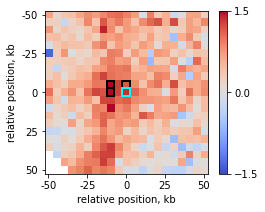

In [53]:
# pick one removed_centroids_0h_overlapped_clusters_new_in_0_6_72h
centroid_df_0h=removed_centroids_0h_overlapped_clusters_new_in_0_6_72h.copy()
centroid_ID_0h=546
library_name='K562_0000min'
centroid_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/dots_meta_5kb_no_HiCCUPS_filtering.tsv'
cluster_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/clusters/clusters_meta_5kb.tsv'
stack_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/stack_of_pileup_of_centroids_in_0h_at_0_6_72_cooler_5kb_resolution_50kb_flank.pickle'
resolution=5000
flank=50000
cluster_color='k'
centroid_color='cyan'

vmax=1.5
vmin=vmax*-1

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/HiC_0h_of_removed_TP_centroid_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


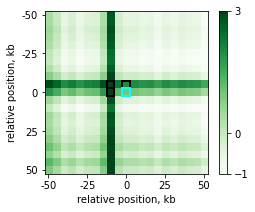

In [54]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/CTCF_CNR_0h_of_removed_TP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


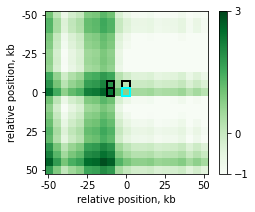

In [55]:
# Rad21
CNR_name='Rad21'
CNR_dict=rad21_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/Rad21_CNR_0h_of_removed_TP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


**6h**

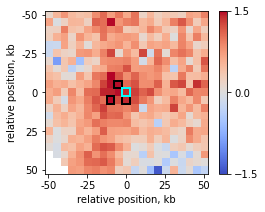

In [56]:
library_name='K562_0360min'

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/HiC_6h_of_removed_TP_centroid_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


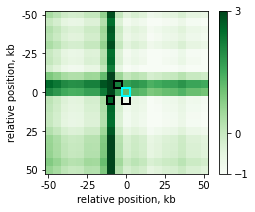

In [57]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/CTCF_CNR_6h_of_removed_TP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


In [19]:
# No Rad21 data at 6h

**72h**

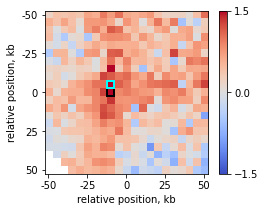

In [58]:
library_name='K562_4320min'

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/HiC_72h_of_removed_TP_centroid_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


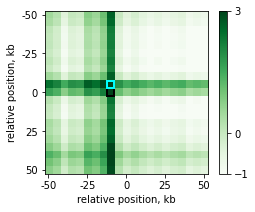

In [59]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/CTCF_CNR_72h_of_removed_TP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


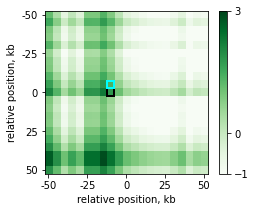

In [60]:
# Rad21
CNR_name='Rad21'
CNR_dict=rad21_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/Rad21_CNR_72h_of_removed_TP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


**Type 1: removed centroids (false positive)**

**0h**

In [11]:
# center pixel in the plot
centroids_df.loc[centroids_df.centroid_ID == 2205]

,chrom1,start1,end1,chrom2,start2,end2,region,c_label,c_size,c_start1,c_end1,c_start2,c_end2,removed,centroid_ID
2205,chr16,25735000,25740000,chr16,25830000,25835000,chr16_p,54,2,25715000,25740000,25825000,25835000,True,2205


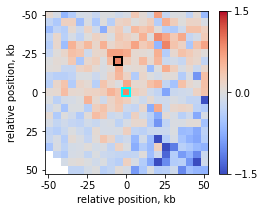

In [61]:
# pick one removed_centroids_0h_overlapped_clusters_new_in_0h_only
centroid_df_0h=removed_centroids_0h_overlapped_clusters_new_in_0h_only.copy()
# pick one ID: 2205
centroid_ID_0h=2205
library_name='K562_0000min'
centroid_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/dots_meta_5kb_no_HiCCUPS_filtering.tsv'
cluster_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/clusters/clusters_meta_5kb.tsv'
stack_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/stack_of_pileup_of_centroids_in_0h_at_0_6_72_cooler_5kb_resolution_50kb_flank.pickle'
resolution=5000
flank=50000
cluster_color='k'
centroid_color='cyan'

vmax=1.5
vmin=vmax*-1

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/HiC_0h_of_removed_FP_centroid_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


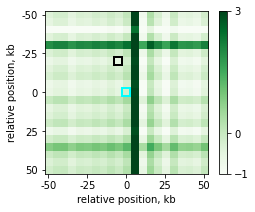

In [62]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/CTCF_CNR_0h_of_removed_FP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


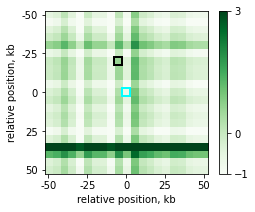

In [63]:
# Rad21
CNR_name='Rad21'
CNR_dict=rad21_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/Rad21_CNR_0h_of_removed_FP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


**6h**

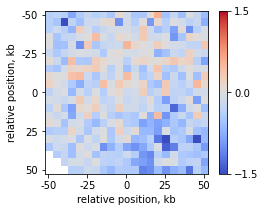

In [64]:
library_name='K562_0360min'

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/HiC_6h_of_removed_FP_centroid_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


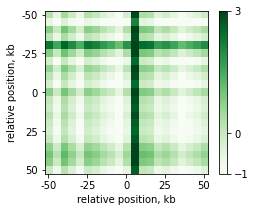

In [65]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/CTCF_CNR_6h_of_removed_FP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


In [28]:
# No Rad21 data at 6h

**72h**

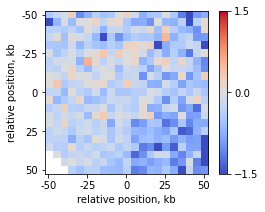

In [66]:
library_name='K562_4320min'

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/HiC_72h_of_removed_FP_centroid_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


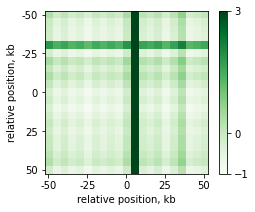

In [67]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/CTCF_CNR_72h_of_removed_FP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


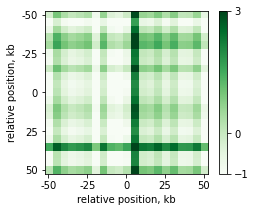

In [68]:
# Rad21
CNR_name='Rad21'
CNR_dict=rad21_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_1/Rad21_CNR_72h_of_removed_FP_centroid_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


**Type 2: removed singletons rescued by MEGA only (true positive)** 

**0h**

In [52]:
# center pixel in the plot
# 216
centroids_df.loc[centroids_df.centroid_ID == 216]

,chrom1,start1,end1,chrom2,start2,end2,region,c_label,c_size,c_start1,c_end1,c_start2,c_end2,removed,centroid_ID
216,chr10,110740000,110745000,chr10,110885000,110890000,chr10_q,100,1,110740000,110745000,110885000,110890000,True,216


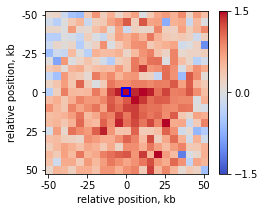

In [57]:
# pick one removed_singletons_0h_in_0h_and_MEGA
centroid_df_0h=removed_singletons_0h_in_0h_and_MEGA.copy()
# 216
centroid_ID_0h=216
library_name='K562_0000min'
centroid_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/dots_meta_5kb_no_HiCCUPS_filtering.tsv'
cluster_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/clusters/clusters_meta_5kb.tsv'
stack_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/stack_of_pileup_of_centroids_in_0h_at_0_6_72_cooler_5kb_resolution_50kb_flank.pickle'
resolution=5000
flank=50000
cluster_color='k'
centroid_color='b'

vmax=1.5
vmin=vmax*-1

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/HiC_0h_of_removed_TP_singleton_specific_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)

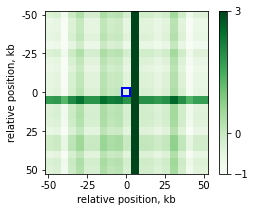

In [58]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/CTCF_CNR_0h_of_removed_TP_singleton_specific_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)

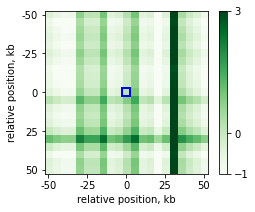

In [59]:
# Rad21
CNR_name='Rad21'
CNR_dict=rad21_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/Rad21_CNR_0h_of_removed_TP_singleton_specific_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)

**6h**

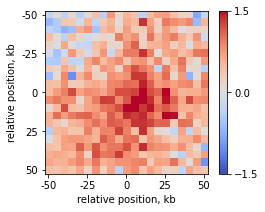

In [60]:
library_name='K562_0360min'
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/HiC_6h_of_removed_TP_singleton_specific_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


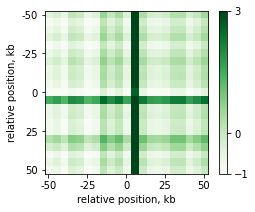

In [61]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/CTCF_CNR_6h_of_removed_TP_singleton_specific_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)

In [62]:
# No Rad21 data at 6h

**72h**

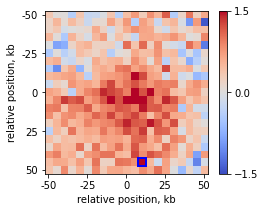

In [63]:
library_name='K562_4320min'

generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin)

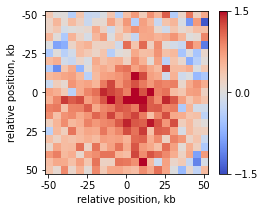

In [64]:
# Do not show loops from different loci for clear comparison
# Since the cluster of 0h and MEGA by unionloops only has 7 pixels.
library_name='K562_4320min'
cluster_color=None
centroid_color=None
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/HiC_72h_of_removed_TP_singleton_specific_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)



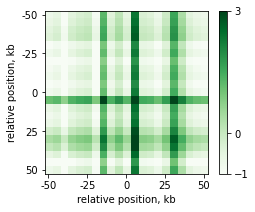

In [65]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/CTCF_CNR_72h_of_removed_TP_singleton_specific_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)

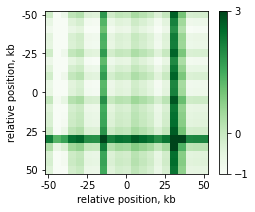

In [66]:
# Rad21
CNR_name='Rad21'
CNR_dict=rad21_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/Rad21_CNR_72h_of_removed_TP_singleton_specific_at_0h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)

**MEGA**

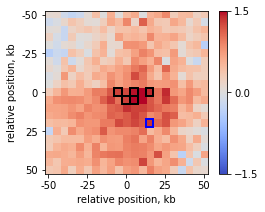

In [67]:
library_name='MEGA'
cluster_color='k'
centroid_color='b'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin)

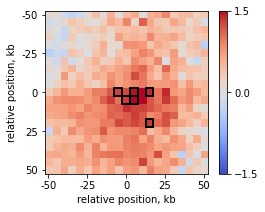

In [68]:
# centroid as black
library_name='MEGA'
cluster_color='k'
centroid_color='k'
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/HiC_MEGA_of_removed_TP_singleton_specific_at_0h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


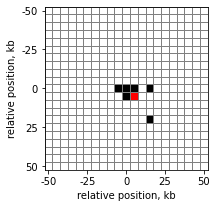

In [69]:
# illustration_new_method

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import pandas as pd

centroid_df_0h=removed_singletons_0h_in_0h_and_MEGA.copy()
centroid_ID_0h=216
cluster_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/clusters/clusters_meta_5kb.tsv'
resolution=5000
flank=50000
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/Corrected_centroid_new_method_of_removed_TP_singleton_specific_at_0h.svg'

centroid_ID_0h_pixel=centroid_df_0h.loc[centroid_df_0h.centroid_ID == centroid_ID_0h, ['chrom1','start1','end1','chrom2','start2','end2']].iloc[0].to_dict()
snippet_region=centroid_ID_0h_pixel.copy()
snippet_region['start1']=snippet_region['start1']-flank
snippet_region['end1']=snippet_region['end1']+flank
snippet_region['start2']=snippet_region['start2']-flank
snippet_region['end2']=snippet_region['end2']+flank

# Create a 21x21 empty matrix filled with np.nan
matrix = np.ones((21, 21, 3))  # Use 3 channels (RGB)

for library_name in ['K562_0000min','MEGA']:
    clusters_meta=pd.read_csv(cluster_library, sep='\t').set_index('name')['path'].to_dict()
    clusters=pd.read_csv(clusters_meta[library_name], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    clusters_in_snippet=clusters.loc[(clusters.chrom1 == snippet_region['chrom1']) &
                                     (clusters.start1 >= snippet_region['start1']) &
                                     (clusters.end1 <= snippet_region['end1']) &
                                     (clusters.chrom2 == snippet_region['chrom2']) &
                                     (clusters.start2 >= snippet_region['start2']) &
                                     (clusters.end2 <= snippet_region['end2'])]

    # centroid_ID_0h_pixel, (10,10) 21*21 matrix
    index1_clusters_in_snippet=[int((start1-centroid_ID_0h_pixel['start1'])/resolution)+10 for start1 in clusters_in_snippet['start1']]
    index2_clusters_in_snippet=[int((start2-centroid_ID_0h_pixel['start2'])/resolution)+10 for start2 in clusters_in_snippet['start2']]
    index_clusters_in_snippet=list(zip(index1_clusters_in_snippet, index2_clusters_in_snippet))
    
    for row, column in index_clusters_in_snippet:
        matrix[row, column] = [0, 0, 0] # Black for enriched pixels

# loop in my new method, for this centroid_ID_0h: 4733,
# (move center pixel one step down)
# (move center pixel one step right)
# See above removed_centroids_0h_in_0h_and_MEGA (compared to centroid index at 0h: 10,10)
matrix[10+1, 10+1]=[255, 0, 0] # Red

plt.figure(figsize=(4, 3))

plt.imshow(matrix)

ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
plt.xticks(ticks_pixels, ticks_kbp)
plt.yticks(ticks_pixels, ticks_kbp)
plt.xlabel('relative position, kb')
plt.ylabel('relative position, kb')

# Get the current axis to add patches
ax = plt.gca()

# add grid
for row in range(21):
    for col in range(21):
        rect = patches.Rectangle((col-0.5, row-0.5), 1, 1, linewidth=1, linestyle='-', edgecolor='grey', facecolor='none')
        ax.add_patch(rect)


# plt.savefig(output, format="svg", dpi=300)


**Example: Centroids in 0h are closed to centroids in 6 and 72h (i.e., not 0h_specific)**

**0h**

In [17]:
# center pixel in the plot
centroids_df.loc[centroids_df.centroid_ID == 2]

,chrom1,start1,end1,chrom2,start2,end2,region,c_label,c_size,c_start1,c_end1,c_start2,c_end2,removed,centroid_ID
2,chr10,32795000,32800000,chr10,33005000,33010000,chr10_p,2,16,32785000,32810000,32995000,33025000,False,2


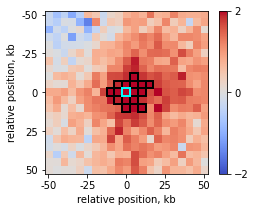

In [24]:
# pick one kept_centroids_0h_overlapped_clusters_new_in_0_6_72h
centroid_df_0h=kept_centroids_0h_overlapped_clusters_new_in_0_6_72h.copy()
# pick one ID: 2
centroid_ID_0h=2
library_name='K562_0000min'
centroid_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/dots_meta_5kb_no_HiCCUPS_filtering.tsv'
cluster_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/clusters/clusters_meta_5kb.tsv'
stack_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/stack_of_pileup_of_centroids_in_0h_at_0_6_72_cooler_5kb_resolution_50kb_flank.pickle'
resolution=5000
flank=50000
cluster_color='k'
centroid_color='cyan'

# vmax=1
# vmin=1*-1
vmax=2
vmin=vmax*-1

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/HiC_0h_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


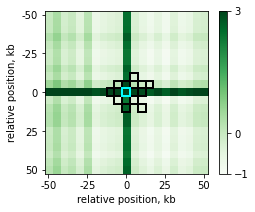

In [80]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/CTCF_CNR_0h_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


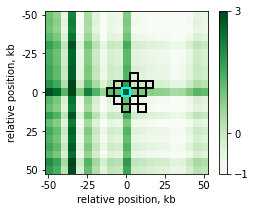

In [81]:
# Rad21
CNR_name='Rad21'
CNR_dict=rad21_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/Rad21_CNR_0h_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


**6h**

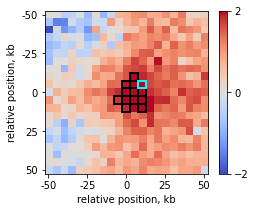

In [82]:
library_name='K562_0360min'

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/HiC_6h_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


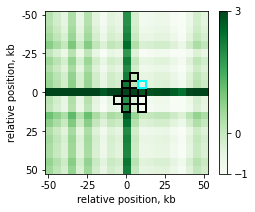

In [83]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/CTCF_CNR_6h_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


In [47]:
# No Rad21 data at 6h

**72h**

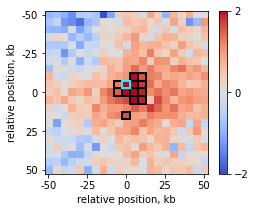

In [84]:
library_name='K562_4320min'

# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/HiC_72h_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


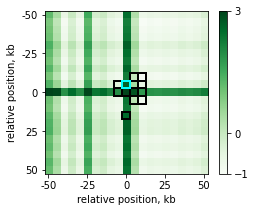

In [85]:
# CTCF
CNR_name='CTCF'
CNR_dict=ctcf_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/CTCF_CNR_72h_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


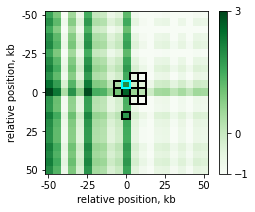

In [86]:
# Rad21
CNR_name='Rad21'
CNR_dict=rad21_bw.copy()
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/Rad21_CNR_72h_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_CNR_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, CNR_name, CNR_dict, resolution, flank, cluster_color, centroid_color, output=output)


**MEGA**

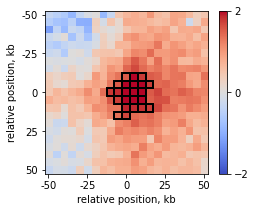

In [87]:
library_name='MEGA'
cluster_color='k'
centroid_color='k' # change centroid color to black
# save as SVG
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/HiC_MEGA_of_kept_TP_centroid_static_at_0_6_72h.svg'
generate_snippet_at_a_centroid_in_0h_in_different_libraries(centroid_df_0h, centroid_ID_0h, library_name, centroid_library, cluster_library, stack_library, resolution, flank, cluster_color, centroid_color, vmax, vmin, output=output)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


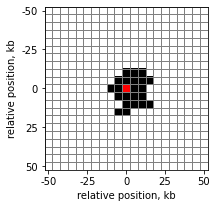

In [88]:
# illustration_new_method

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import pandas as pd

centroid_df_0h=kept_centroids_0h_overlapped_clusters_new_in_0_6_72h.copy()
centroid_ID_0h=2
cluster_library='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/clusters/clusters_meta_5kb.tsv'
resolution=5000
flank=50000
output='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_3/Corrected_centroid_new_method_of_kept_TP_centroid_static_at_0_6_72h.svg'

centroid_ID_0h_pixel=centroid_df_0h.loc[centroid_df_0h.centroid_ID == centroid_ID_0h, ['chrom1','start1','end1','chrom2','start2','end2']].iloc[0].to_dict()
snippet_region=centroid_ID_0h_pixel.copy()
snippet_region['start1']=snippet_region['start1']-flank
snippet_region['end1']=snippet_region['end1']+flank
snippet_region['start2']=snippet_region['start2']-flank
snippet_region['end2']=snippet_region['end2']+flank

# Create a 21x21 empty matrix filled with np.nan
matrix = np.ones((21, 21, 3))  # Use 3 channels (RGB)

for library_name in ['K562_0000min','K562_0360min','K562_4320min','MEGA']:
    clusters_meta=pd.read_csv(cluster_library, sep='\t').set_index('name')['path'].to_dict()
    clusters=pd.read_csv(clusters_meta[library_name], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    clusters_in_snippet=clusters.loc[(clusters.chrom1 == snippet_region['chrom1']) &
                                     (clusters.start1 >= snippet_region['start1']) &
                                     (clusters.end1 <= snippet_region['end1']) &
                                     (clusters.chrom2 == snippet_region['chrom2']) &
                                     (clusters.start2 >= snippet_region['start2']) &
                                     (clusters.end2 <= snippet_region['end2'])]

    # centroid_ID_0h_pixel, (10,10) 21*21 matrix
    index1_clusters_in_snippet=[int((start1-centroid_ID_0h_pixel['start1'])/resolution)+10 for start1 in clusters_in_snippet['start1']]
    index2_clusters_in_snippet=[int((start2-centroid_ID_0h_pixel['start2'])/resolution)+10 for start2 in clusters_in_snippet['start2']]
    index_clusters_in_snippet=list(zip(index1_clusters_in_snippet, index2_clusters_in_snippet))
    
    for row, column in index_clusters_in_snippet:
        matrix[row, column] = [0, 0, 0] # Black for enriched pixels

# loop in my new method, for this centroid_ID_0h: 2, in the center (compared to centroid index at 0h: 10,10)
# See kept_centroids_0h_overlapped_clusters_new_in_0_6_72h above compared to 0h centroid
matrix[10, 10]=[255, 0, 0] # Red

plt.figure(figsize=(4, 3))

plt.imshow(matrix)

ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
plt.xticks(ticks_pixels, ticks_kbp)
plt.yticks(ticks_pixels, ticks_kbp)
plt.xlabel('relative position, kb')
plt.ylabel('relative position, kb')

# Get the current axis to add patches
ax = plt.gca()

# add grid
for row in range(21):
    for col in range(21):
        rect = patches.Rectangle((col-0.5, row-0.5), 1, 1, linewidth=1, linestyle='-', edgecolor='grey', facecolor='none')
        ax.add_patch(rect)

plt.savefig(output, format="svg", dpi=300)

